In [34]:
import seaborn as sns
import pandas as pd

In [35]:
df = pd.read_csv("output.txt")
df

,step,page,count,model_selection,model_score,arms_score
0,1,140688847011840,28028.0,0,0.000000e+00,0.000000e+00
1,1,140688865886208,21021.0,0,0.000000e+00,0.000000e+00
2,1,140688861691904,17017.0,0,0.000000e+00,0.000000e+00
3,1,140688851206144,36036.0,0,0.000000e+00,0.000000e+00
4,1,140688855400448,28028.0,0,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
2050029,629,140688834428928,14489500.0,1,1.723120e+07,1.048540e+07
2050030,629,140688874274816,4004.0,1,3.303990e+03,4.970910e+03
2050031,629,140659931480064,0.0,0,8.060850e+02,3.444270e+01
2050032,629,140661560967168,0.0,0,8.060850e+02,7.832890e+01


In [36]:
def set_target(group):
    group = group.sort_values("step")
    group["Target"] = group["count"].shift(-1)
    group = group.dropna()
    return group

df = df.groupby(["page"], group_keys=False).apply(
    set_target
).reset_index(drop=True)

/tmp/ipykernel_2177804/2617714390.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["page"], group_keys=False).apply(


In [37]:
# Group by 'page' and 'step', then compute the exponentially weighted moving average (EWMA) over 'count'
ewma_df = (
    df.sort_values(['page', 'step'])
      .groupby('page')
      .apply(lambda x: x.set_index('step')['count'].ewm(span=5, adjust=False).mean())
      .reset_index()
      .rename(columns={'count': 'count_ewma'})
)

/tmp/ipykernel_2177804/665497493.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.set_index('step')['count'].ewm(span=5, adjust=False).mean())


<Axes: xlabel='step', ylabel='page'>

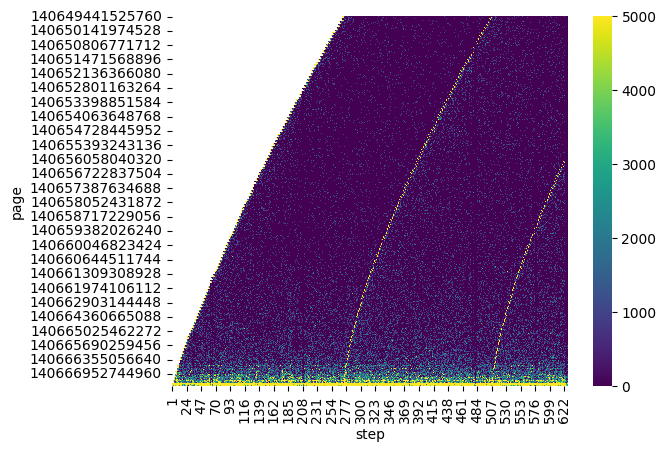

In [38]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_pebs = df.pivot(index='page', columns='step', values='count')

# Plot the heatmap
sns.heatmap(pivot_df_pebs, cmap='viridis', vmin=0, vmax=5000)

<Axes: xlabel='step', ylabel='page'>

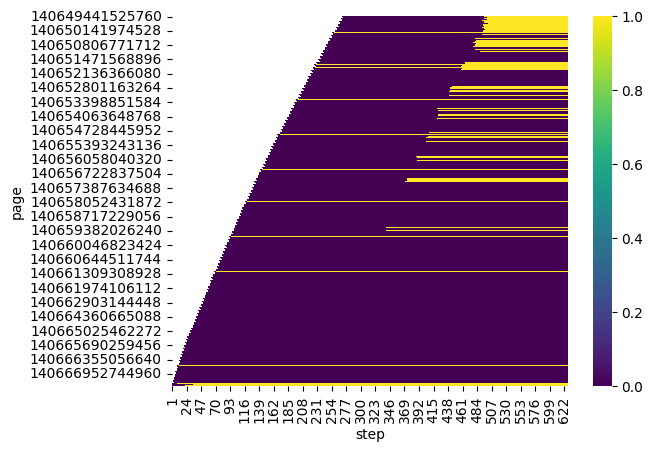

In [39]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df = df.pivot(index='page', columns='step', values='model_selection')

# Plot the heatmap
sns.heatmap(pivot_df, cmap='viridis', vmax=1)

In [40]:
df["model_error"] = ((df["model_score"]) - df["count"]) / (df["count"].replace(0, 1))
df["arms_error"] = (df["arms_score"] - df["count"]) / (df["count"].replace(0, 1))

<Axes: xlabel='step', ylabel='page'>

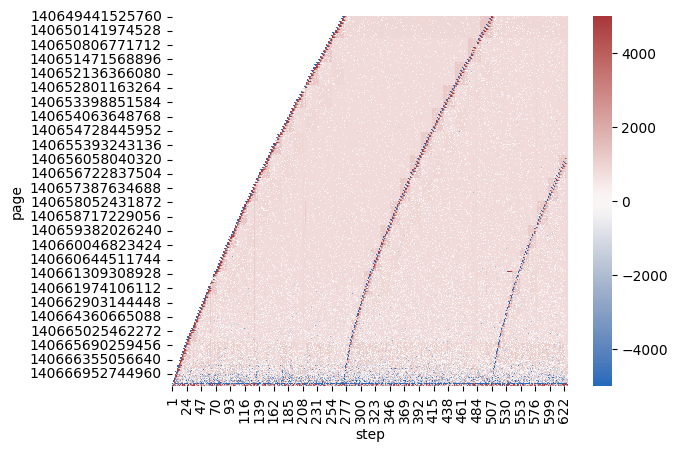

In [41]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_model = df.pivot(index='page', columns='step', values='model_score')

# Plot the heatmap
sns.heatmap(pivot_df_model - pivot_df_pebs, cmap='vlag', vmax=5000, vmin=-5000)

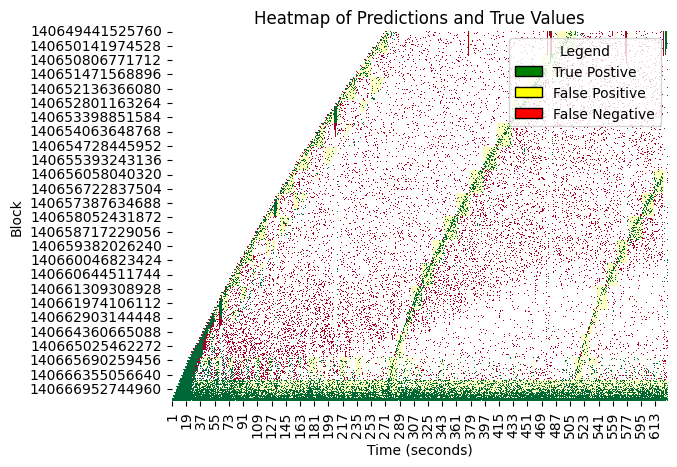

In [42]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values(["step", "Target"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_true = result_df_top.pivot_table(index='page', columns='step', values='Target', aggfunc=lambda x: 1 if len(x) > 0 else 0)
df = df.sort_values(["step", "model_score"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_pred = result_df_top.pivot_table(index='page', columns='step', values='model_score', aggfunc=lambda x: 1 if len(x) > 0 else 0)

sns.heatmap((heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan), cmap="RdYlGn", cbar=False).set(ylabel="Block", xlabel="Time (seconds)")
plt.title("Heatmap of Predictions and True Values")

# Add a custom legend
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='True Postive'),
    Patch(facecolor='yellow', edgecolor='black', label='False Positive'),
    Patch(facecolor='red', edgecolor='black', label='False Negative')
]
plt.legend(handles=legend_elements, loc='upper right', title="Legend")

(150.0, 200.0)

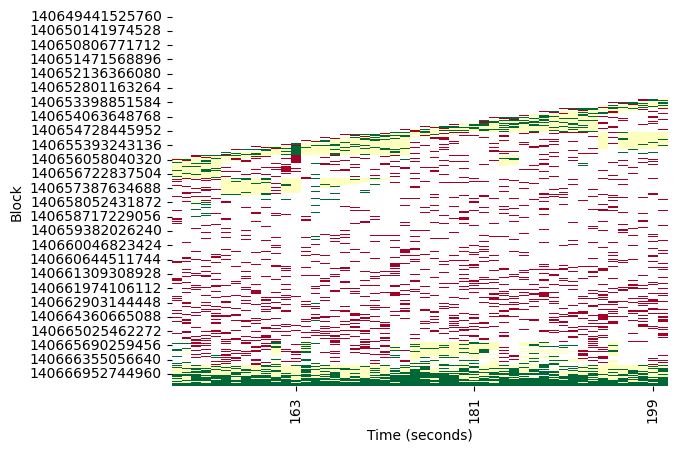

In [43]:
sns.heatmap((heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan), cmap="RdYlGn", cbar=False).set(ylabel="Block", xlabel="Time (seconds)")
plt.xlim(150, 200)

<Axes: xlabel='step', ylabel='page'>

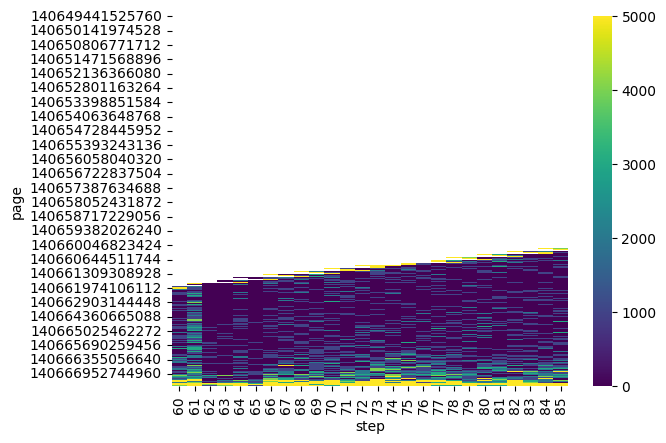

In [44]:
sns.heatmap(pivot_df_pebs.loc[:, 60:85], cmap='viridis', vmax=5000)

<Axes: xlabel='step', ylabel='page'>

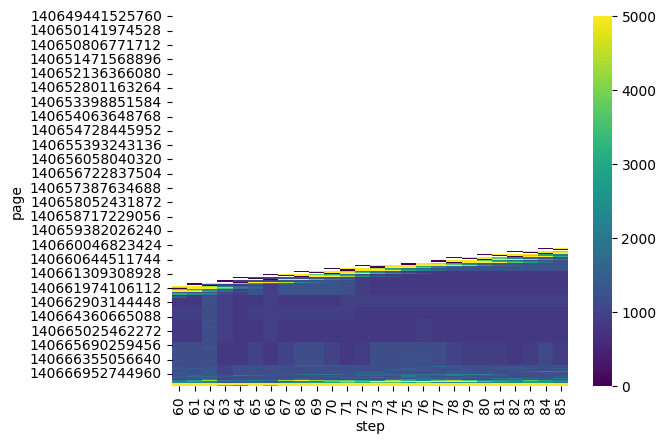

In [45]:
sns.heatmap(pivot_df_model.loc[:, 60:85], cmap='viridis', vmax=5000, vmin=0)

<Axes: xlabel='step', ylabel='page'>

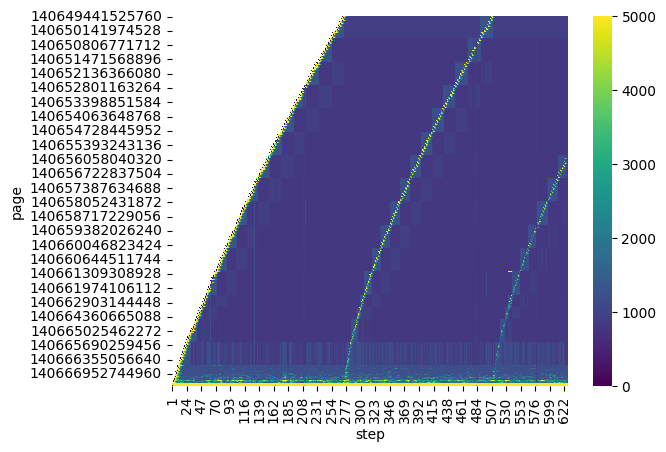

In [46]:
sns.heatmap(pivot_df_model, cmap='viridis', vmax=5000, vmin=0)

<Axes: xlabel='step', ylabel='page'>

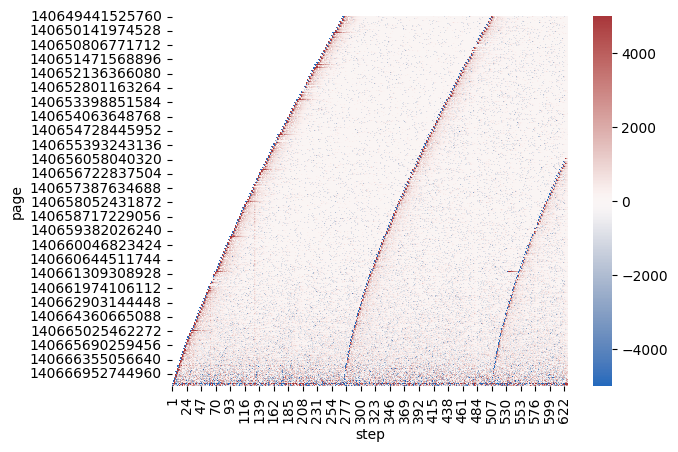

In [47]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_arms = df.pivot(index='page', columns='step', values='arms_score')

# Plot the heatmap
sns.heatmap(pivot_df_arms - pivot_df_pebs, cmap='vlag', vmax=5000, vmin=-5000)

<Axes: xlabel='step', ylabel='page'>

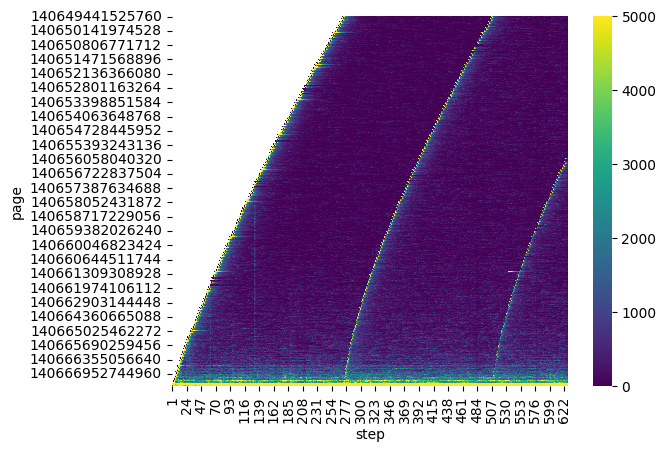

In [48]:
sns.heatmap(pivot_df_arms, cmap='viridis', vmax=5000, vmin=0)